<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 1, Conversión a Problema Supervisado**

### **A) Toy Dataset**

Importamos las librerias necesarias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Definimos la semilla y el toy dataset

In [ ]:
np.random.seed(42)
t = np.arange(100)
y = 0.5 * t + 10 * np.sin(t / 10) + np.random.normal(0, 5, len(t))

In [ ]:
print(t)
print("_"*20)
print(y)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
____________________
[ 2.48357077  0.80701266  6.225136   12.07035135  4.72341655  6.1235706
 16.54248881 13.77935052  8.82618898 15.04606931 11.09762138 12.08342483
 16.53020222  6.56918063  8.22990814 14.66351222 12.93158043 19.98788477
 14.19835593 11.90148237 26.42121811 18.00321216 19.42260506 11.83331119
 16.03271818 19.03933439 12.40004583 19.65228889 14.34668805 15.43402454
 13.40266702 25.17719755 15.34877244  9.63398841 18.55731354  7.88794947
 14.61911354  3.40328797  6.24049085 13.60664459 16.12430795 13.1740703
 11.70600086 10.83282215  5.09136931  9.12547778 10.75989611 18.78637856
 15.75644536  5.8602731  17.0311771  14.31644177 13.78084344 21.23570702
 24.42735274 25.10

### **Rolling Window**

Es una ventana sobre la que calculamos un estadístico, en este caso: una media. La media es calculada sobre una ventana de tamaño fijo que se desplaza. El tamaño nunca cambia, solo avanza.

In [ ]:
window_size = 10
rolling_mean = np.array([
    y[i - window_size:i].mean()
    for i in range(window_size, len(y) + 1)
])

In [ ]:
rolling_mean[0]

np.float64(8.662715554669596)

In [ ]:
#Probando la media
pm = (2.48357077 + 0.80701266 + 6.225136 + 12.07035135 + 4.72341655 + 6.1235706 + 16.54248881 + 13.77935052 + 8.82618898 + 15.04606931)/10
print(pm)

8.662715555


Visualizamos los resultados

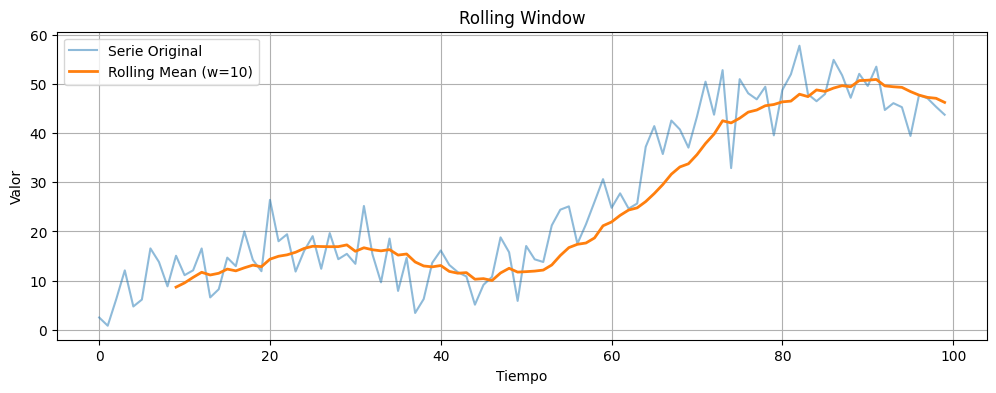

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, y, label='Serie Original', alpha=0.5)
plt.plot(t[window_size - 1:], rolling_mean, label=f'Rolling Mean (w={window_size})', linewidth=2)
plt.title('Rolling Window')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### **Expanding Window**

Es una ventana sobre la que calculamos un estadístico, en este caso: una media.  La ventana arranca en el origen y crece con cada paso. Usa toda la historia disponible.

In [ ]:
expanding_mean = np.array([
    y[:i].mean()
    for i in range(1, len(y) + 1)
])

Visualizamos los resultados

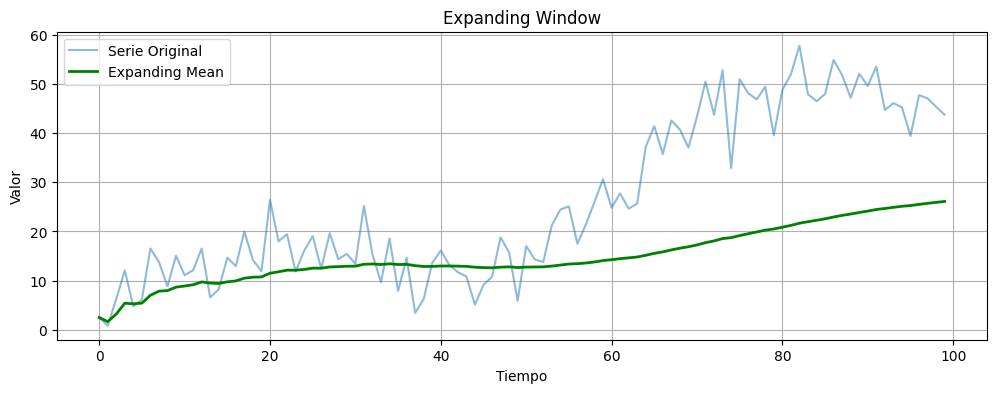

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, y, label='Serie Original', alpha=0.5)
plt.plot(t, expanding_mean, label='Expanding Mean', linewidth=2, color='green')
plt.title('Expanding Window')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### **Rolling vs Expanding, Comparación Visual**

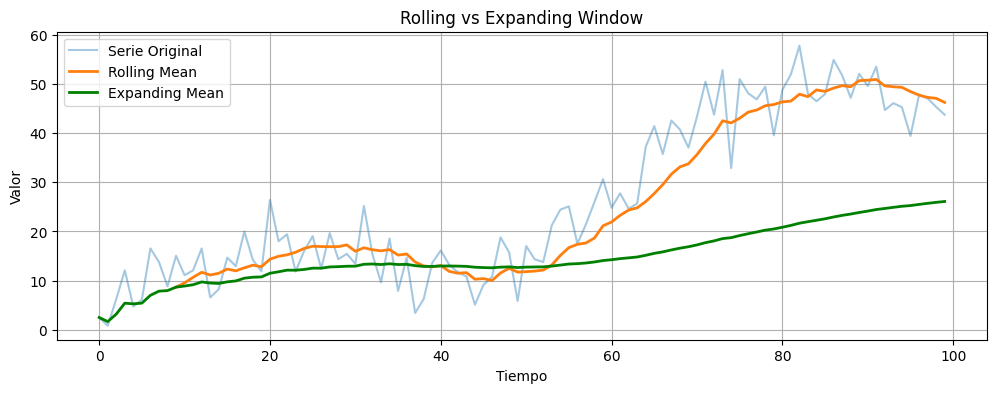

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(t, y, label='Serie Original', alpha=0.4)
plt.plot(t[window_size - 1:], rolling_mean, label='Rolling Mean', linewidth=2)
plt.plot(t, expanding_mean, label='Expanding Mean', linewidth=2, color='green')
plt.title('Rolling vs Expanding Window')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

### **B) AirPassengers Dataset**

Importamos lo necesario

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.datasets import get_rdataset

Importamos el dataset de AirPassengers

In [ ]:
data = get_rdataset("AirPassengers").data
y = data["value"].values
t = np.arange(len(y))

In [ ]:
print(y)

[112 118 132 129 121 135 148 148 136 119 104 118 115 126 141 135 125 149
 170 170 158 133 114 140 145 150 178 163 172 178 199 199 184 162 146 166
 171 180 193 181 183 218 230 242 209 191 172 194 196 196 236 235 229 243
 264 272 237 211 180 201 204 188 235 227 234 264 302 293 259 229 203 229
 242 233 267 269 270 315 364 347 312 274 237 278 284 277 317 313 318 374
 413 405 355 306 271 306 315 301 356 348 355 422 465 467 404 347 305 336
 340 318 362 348 363 435 491 505 404 359 310 337 360 342 406 396 420 472
 548 559 463 407 362 405 417 391 419 461 472 535 622 606 508 461 390 432]


In [ ]:
print(t)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143]


Visualizamos el dataset

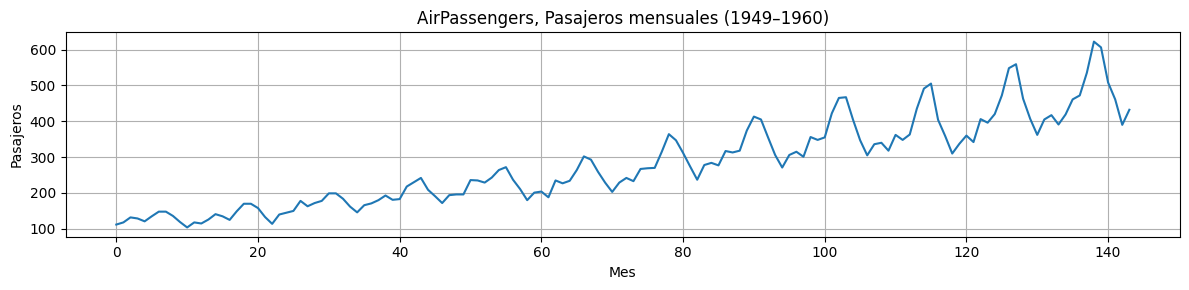

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(y)
plt.title("AirPassengers, Pasajeros mensuales (1949–1960)")
plt.xlabel("Mes")
plt.ylabel("Pasajeros")
plt.grid(True)
plt.tight_layout()
plt.show()

Creamos features con lags

In [ ]:
def make_features(series, input_size):
    X, Y = [], []
    for i in range(input_size, len(series)):
        X.append(series[i - input_size:i])
        Y.append(series[i])
    return np.array(X), np.array(Y)

Usamos los últimos 12 meses parar predecir el siguiente

In [ ]:
INPUT_SIZE = 12

Mínimo de muestras para arrancar a entrenar

In [ ]:
MIN_TRAIN = 24

Aplicamos la función

In [ ]:
X, Y = make_features(y, INPUT_SIZE)

In [ ]:
print(X)
print("_"*20)
print(Y)

[[112 118 132 ... 119 104 118]
 [118 132 129 ... 104 118 115]
 [132 129 121 ... 118 115 126]
 ...
 [407 362 405 ... 622 606 508]
 [362 405 417 ... 606 508 461]
 [405 417 391 ... 508 461 390]]
____________________
[115 126 141 135 125 149 170 170 158 133 114 140 145 150 178 163 172 178
 199 199 184 162 146 166 171 180 193 181 183 218 230 242 209 191 172 194
 196 196 236 235 229 243 264 272 237 211 180 201 204 188 235 227 234 264
 302 293 259 229 203 229 242 233 267 269 270 315 364 347 312 274 237 278
 284 277 317 313 318 374 413 405 355 306 271 306 315 301 356 348 355 422
 465 467 404 347 305 336 340 318 362 348 363 435 491 505 404 359 310 337
 360 342 406 396 420 472 548 559 463 407 362 405 417 391 419 461 472 535
 622 606 508 461 390 432]


Realizamos Walk-forward Validation

In [ ]:
n = len(X)
preds_sliding = []
preds_expanding = []
y_true = []

Definimos tamaño fijo para sliding window

Es una ventana de datos de entrenamiento

In [ ]:
WINDOW_SIZE = 24

In [ ]:
for i in range(MIN_TRAIN, n):
    # la fila que queremos predecir
    X_test_i = X[i].reshape(1, -1)
    # su valor real
    y_true.append(Y[i])

    # Expanding: entrena con todo lo anterior
    X_train_exp = X[:i]
    y_train_exp = Y[:i]
    m_exp = LinearRegression()
    m_exp.fit(X_train_exp, y_train_exp)
    preds_expanding.append(m_exp.predict(X_test_i)[0])

    # Sliding: entrena solo con la ventana fija más reciente
    start = max(0, i - WINDOW_SIZE)
    X_train_sli = X[start:i]
    y_train_sli = Y[start:i]
    m_sli = LinearRegression()
    m_sli.fit(X_train_sli, y_train_sli)
    preds_sliding.append(m_sli.predict(X_test_i)[0])

Convertimos a numpy arrays

In [ ]:
y_true = np.array(y_true)
preds_sliding = np.array(preds_sliding)
preds_expanding = np.array(preds_expanding)

Calculamos el MAE

In [ ]:
mae_sli = mean_absolute_error(y_true, preds_sliding)
mae_exp = mean_absolute_error(y_true, preds_expanding)

In [ ]:
print(f"MAE, Sliding Window  (size={WINDOW_SIZE}): {mae_sli:.2f}")
print(f"MAE, Expanding Window: {mae_exp:.2f}")

MAE, Sliding Window  (size=24): 17.66
MAE, Expanding Window: 13.86


Visualizamos las predicciones

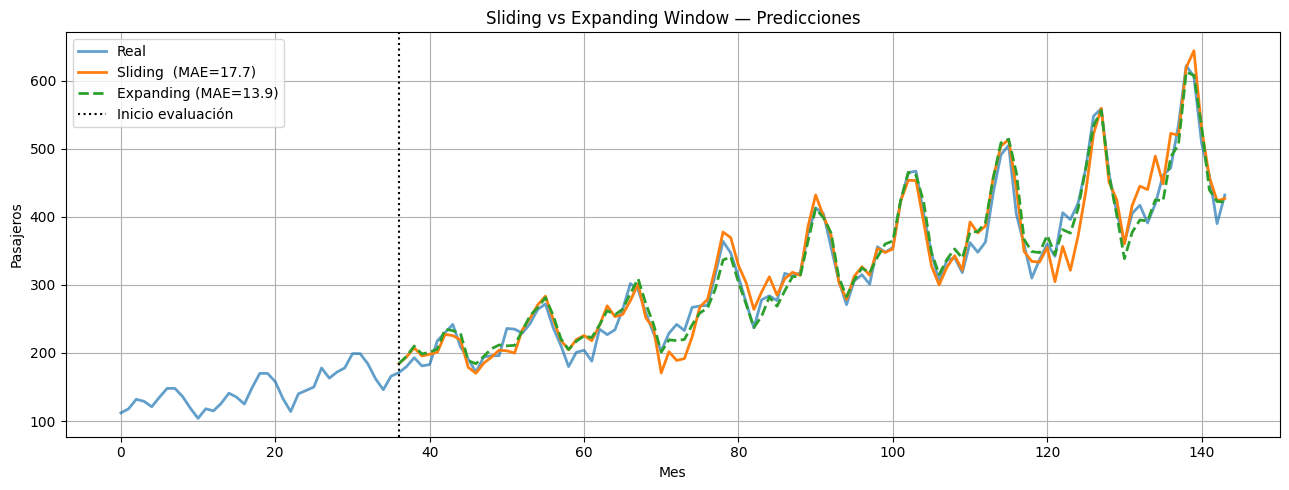

In [ ]:
test_idx = np.arange(MIN_TRAIN + INPUT_SIZE, len(y))

plt.figure(figsize=(13, 5))
plt.plot(y, label='Real', linewidth=2, alpha=0.7)
plt.plot(test_idx, preds_sliding,   label=f'Sliding  (MAE={mae_sli:.1f})', linewidth=2)
plt.plot(test_idx, preds_expanding, label=f'Expanding (MAE={mae_exp:.1f})', linewidth=2, linestyle='--')
plt.axvline(MIN_TRAIN + INPUT_SIZE, color='black', linestyle=':', label='Inicio evaluación')
plt.title('Sliding vs Expanding Window — Predicciones')
plt.xlabel('Mes')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Con este dataset ganó el expanding (MAE 13.86 vs 17.66) porque la regresión estima 13 parámetros (12 lags + intercepto) y al sliding sus 24 muestras le quedan cortas: modelo ruidoso. El expanding, con hasta 131 filas, estima los coeficientes con menos varianza, y ese beneficio supera al costo de arrastrar años viejos.

**Visualizamos el Error Absoluto por Paso**

In [ ]:
err_sli = np.abs(y_true - preds_sliding)
err_exp = np.abs(y_true - preds_expanding)

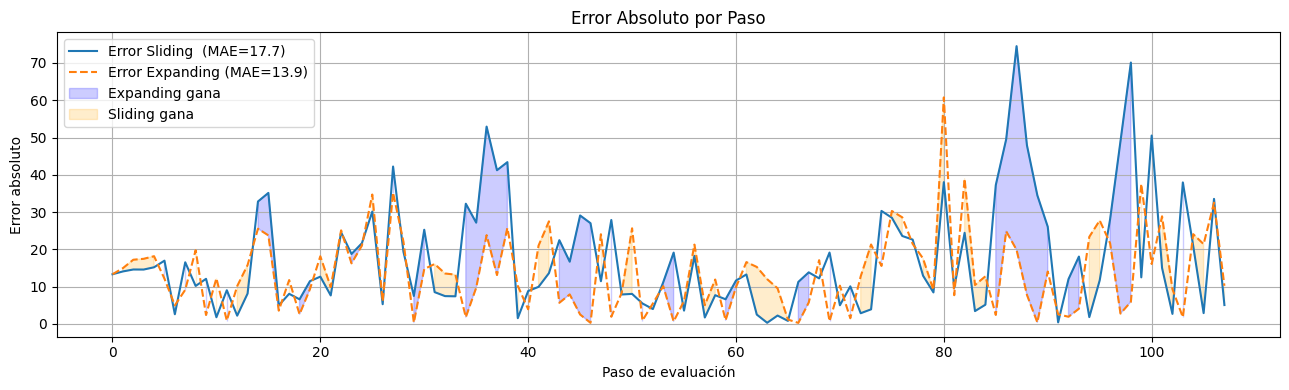

In [ ]:
plt.figure(figsize=(13, 4))
plt.plot(err_sli, label=f'Error Sliding  (MAE={mae_sli:.1f})',   linewidth=1.5)
plt.plot(err_exp, label=f'Error Expanding (MAE={mae_exp:.1f})',  linewidth=1.5, linestyle='--')
plt.fill_between(range(len(err_sli)), err_sli, err_exp,
                 where=err_sli > err_exp, alpha=0.2, color='blue',  label='Expanding gana')
plt.fill_between(range(len(err_sli)), err_sli, err_exp,
                 where=err_sli < err_exp, alpha=0.2, color='orange', label='Sliding gana')
plt.title('Error Absoluto por Paso')
plt.xlabel('Paso de evaluación')
plt.ylabel('Error absoluto')
plt.legend()
plt.grid(True)c
plt.tight_layout()
plt.show()

El MAE resume todo en un número y dice "expanding mejor". Pero este gráfico revela que la realidad es "expanding es más robusto a los picos, sliding es competitivo o mejor en los tramos estables". Es la diferencia entre una métrica agregada y la distribución del error en el tiempo.